#Step 1:  Initial Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np  # Import numpy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt # we will be using matplotlib along with altair
import seaborn as sns

# Set display options (optional, but good for exploration)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load the data
df = pd.read_csv('/content/sample_data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Drop 'Over18' (as you did before)
df.drop('Over18', axis=1, inplace=True)
df.drop('EmployeeCount', axis=1, inplace=True)  # Also not useful
df.drop('StandardHours', axis=1, inplace=True)    # All same value
df.drop('EmployeeNumber', axis=1, inplace=True)   # Unique ID, not predictive

# Step 2: Exploratory Data Analysis (EDA) and Visualizations


## 2.1 Overall Attrition Rate

The attrition rate is: 16.12%


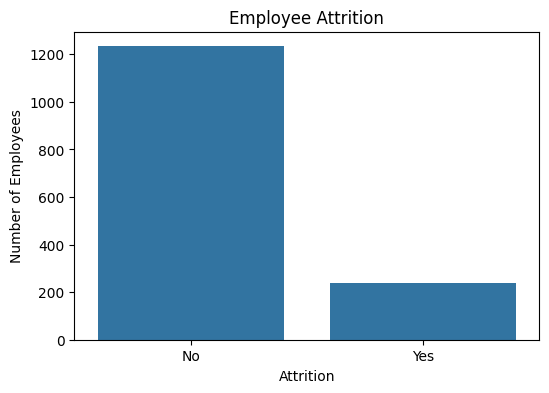

In [ ]:
# Calculate attrition rate (as before)
num_employees_left = df['Attrition'].value_counts()['Yes']  # Another good way to count
total_employees = df.shape[0]
attrition_rate = (num_employees_left / total_employees) * 100
print(f"The attrition rate is: {attrition_rate:.2f}%")

# Simple Bar Chart of Attrition
attrition_counts = df['Attrition'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=attrition_counts.index, y=attrition_counts.values)
plt.title('Employee Attrition')
plt.ylabel('Number of Employees')
plt.show()

## 2.2 Explore Categorical Features

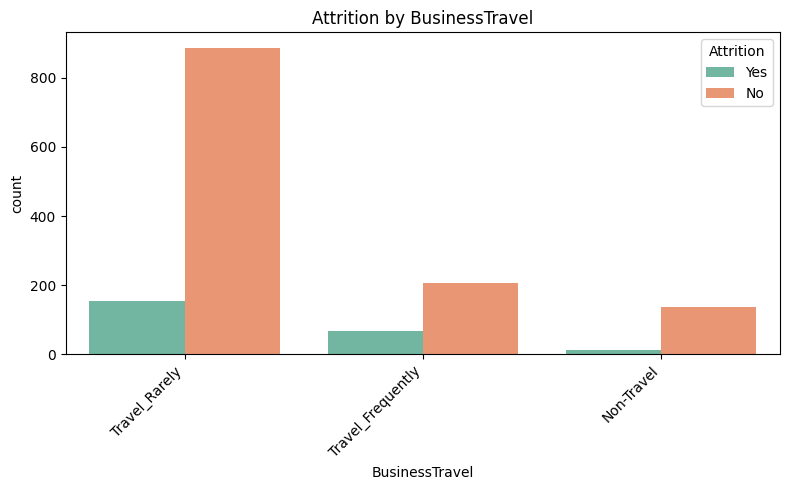

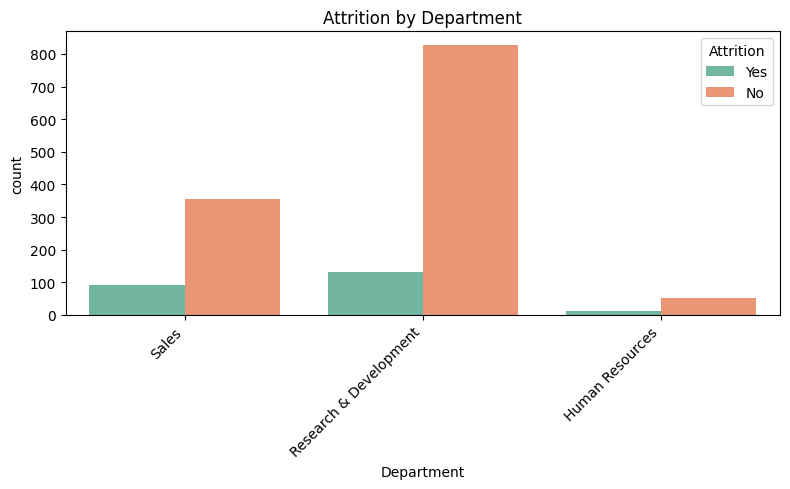

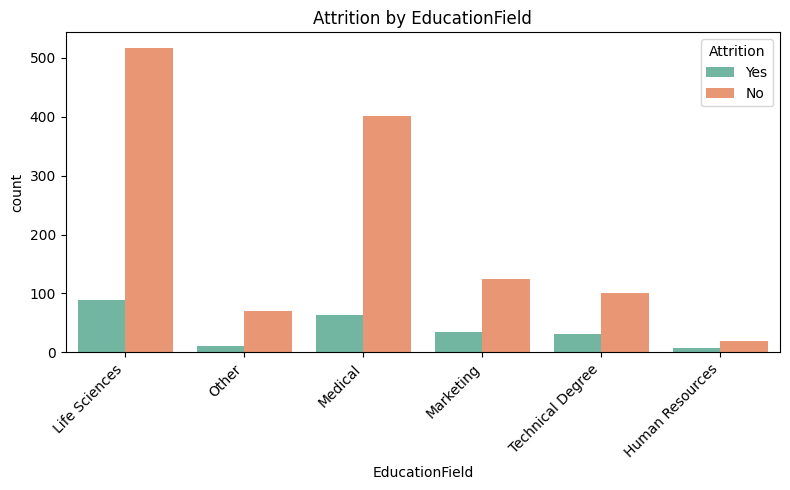

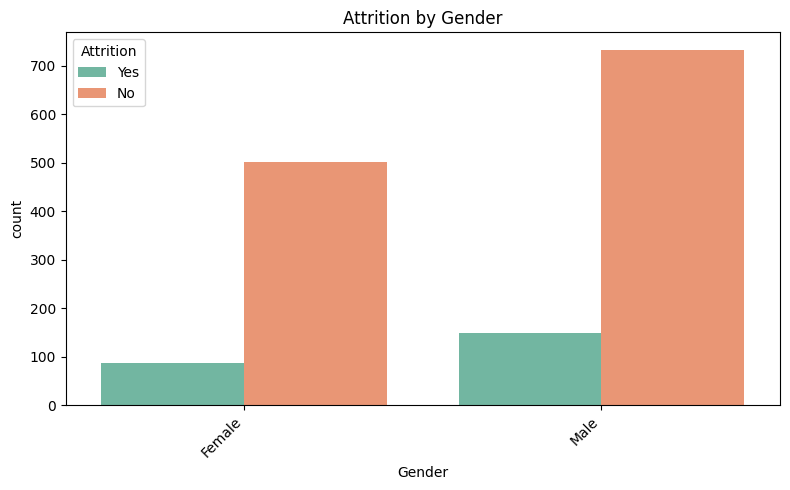

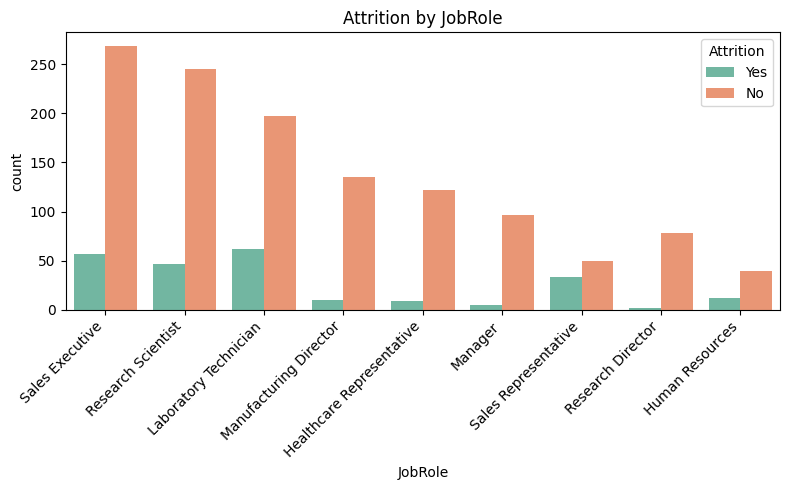

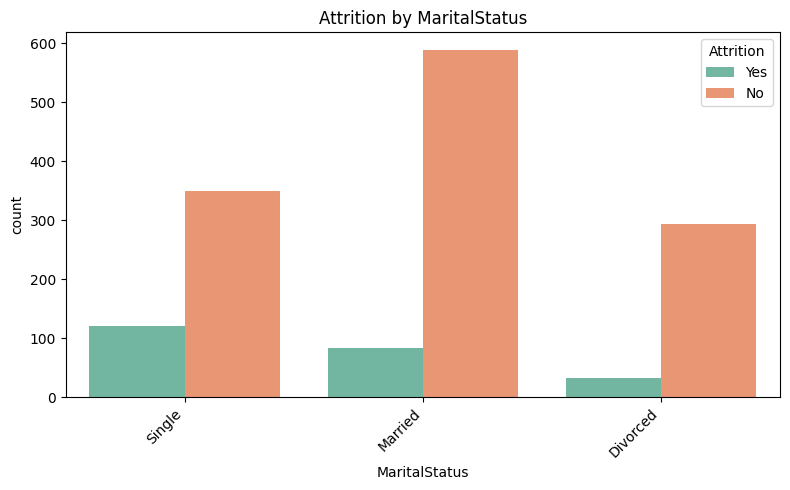

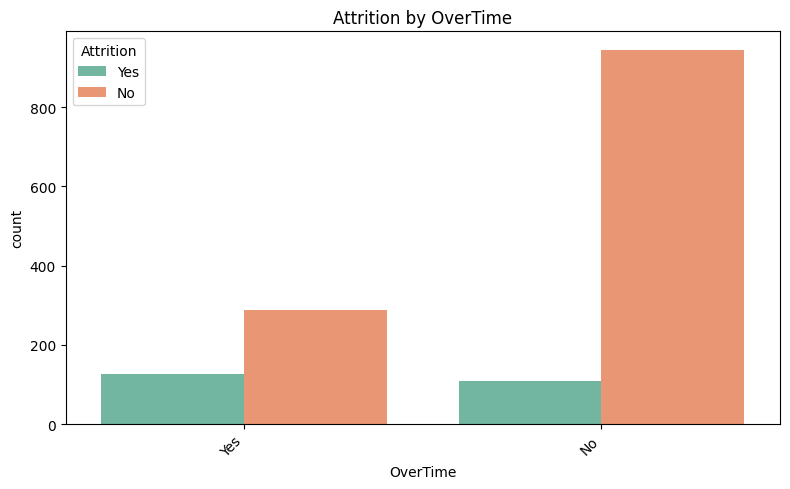

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.drop('Attrition')

for col in categorical_cols:
    plt.figure(figsize=(8, 5))  # Adjust figure size as needed
    sns.countplot(x=col, hue='Attrition', data=df, palette="Set2") # added a palette
    plt.title(f'Attrition by {col}')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.show()

## 2.3 Explore Numerical Features

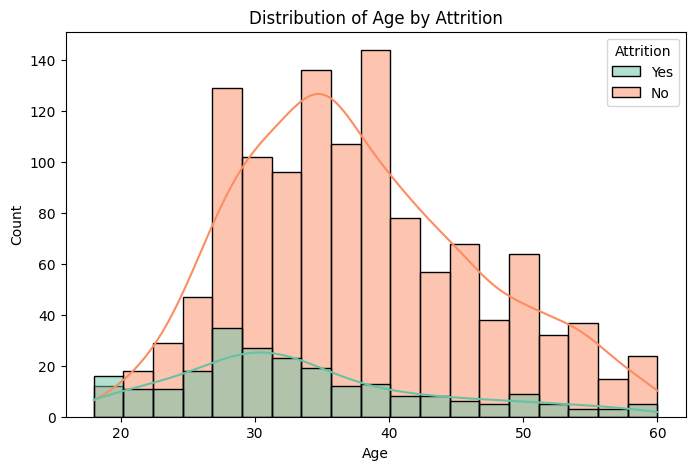

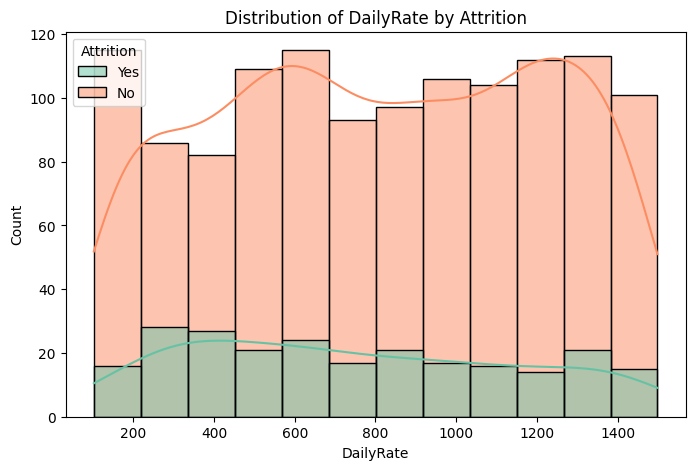

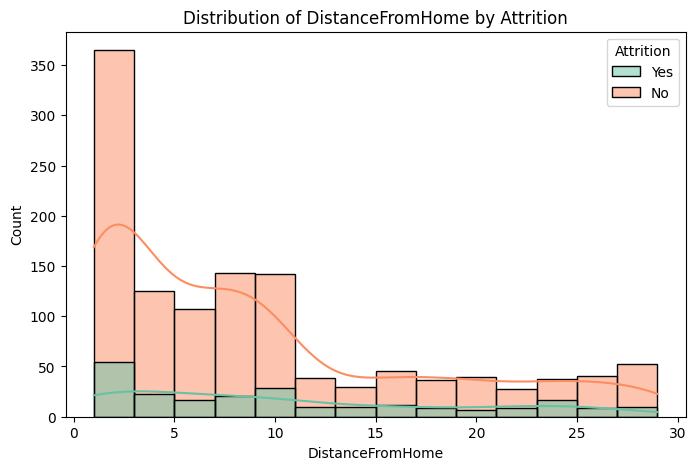

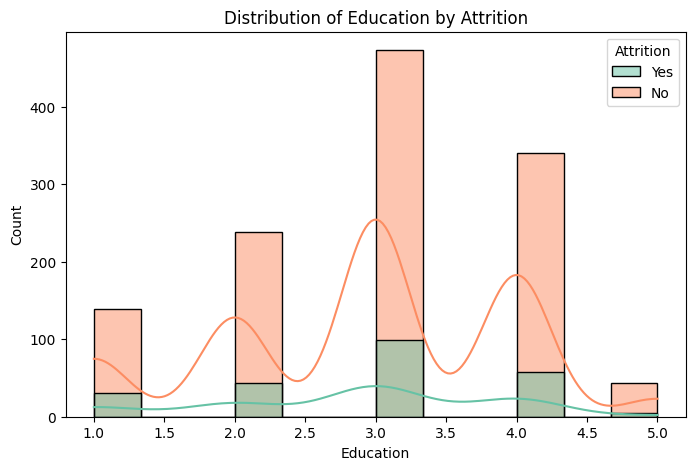

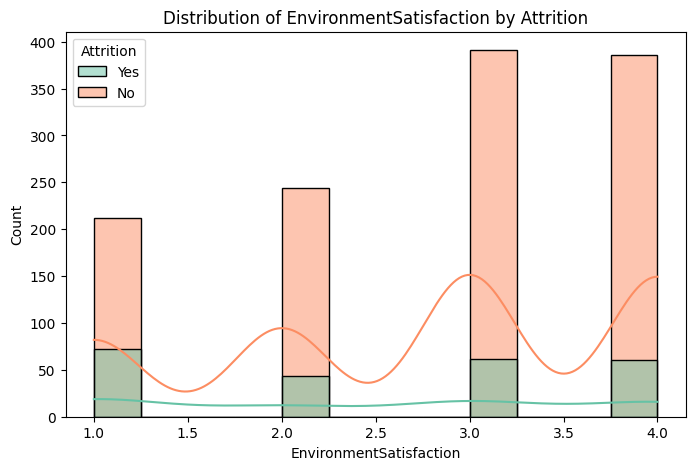

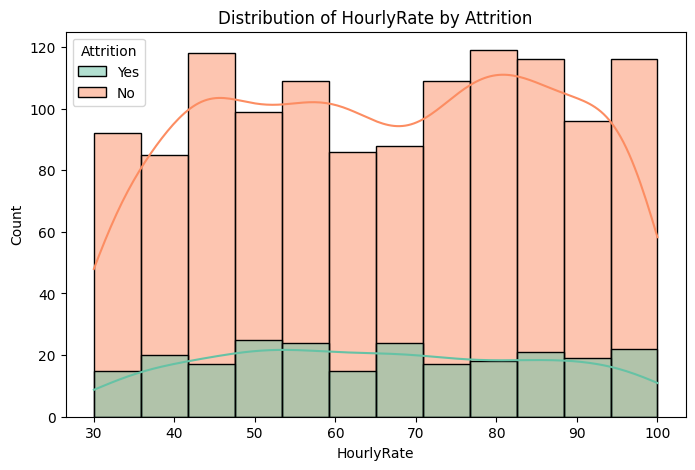

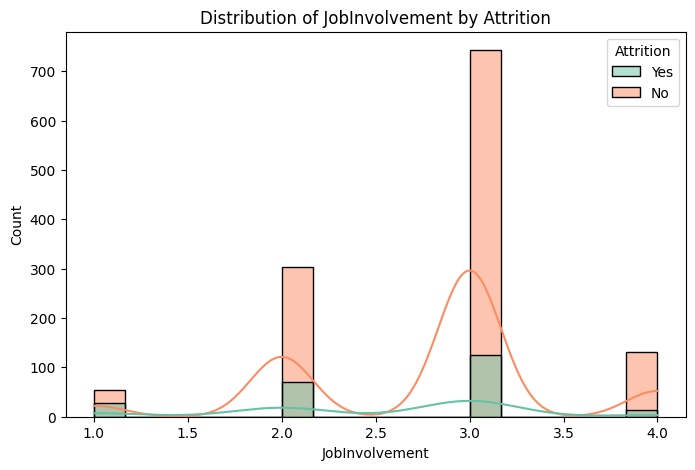

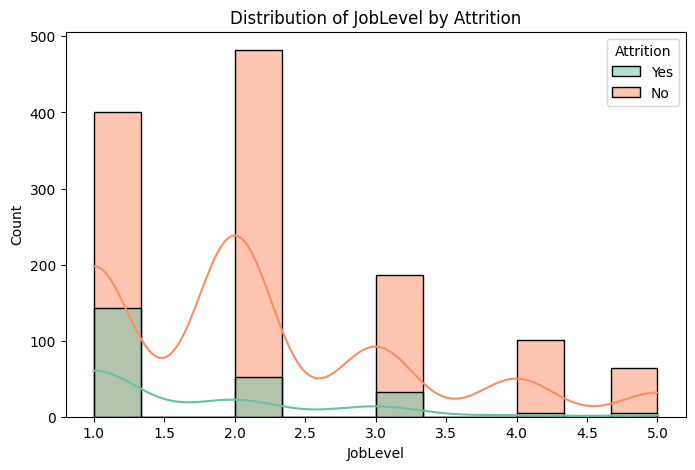

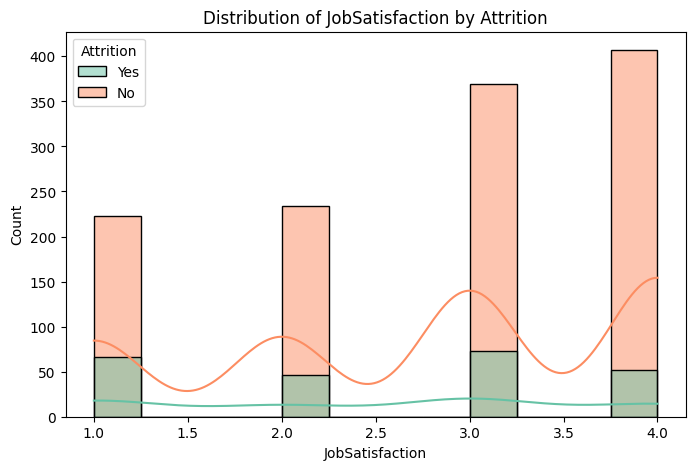

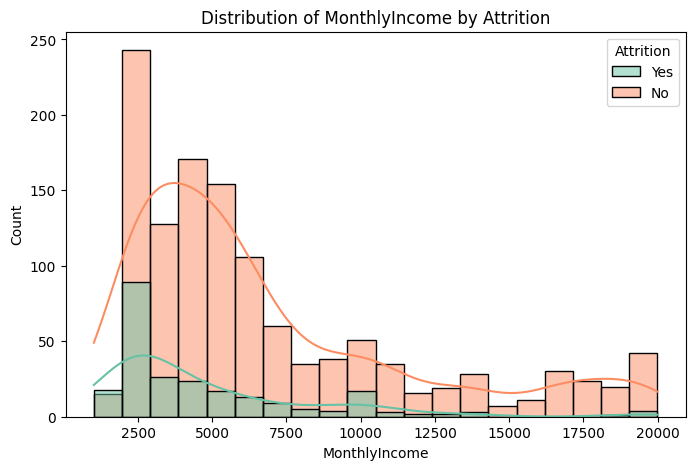

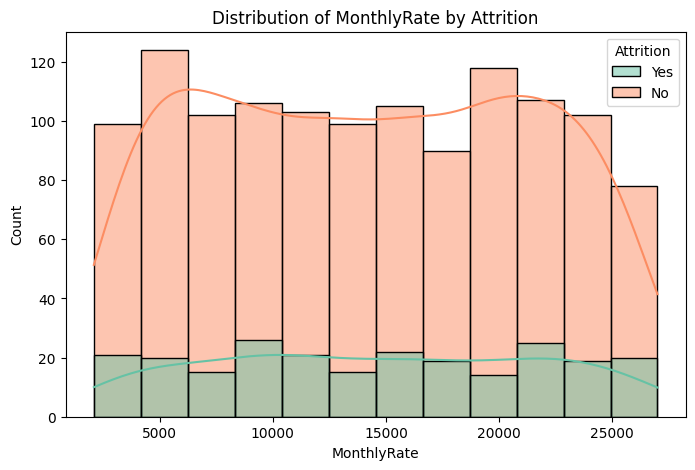

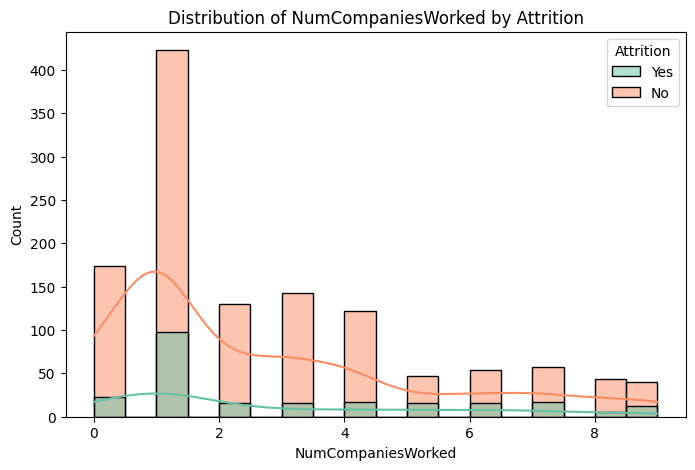

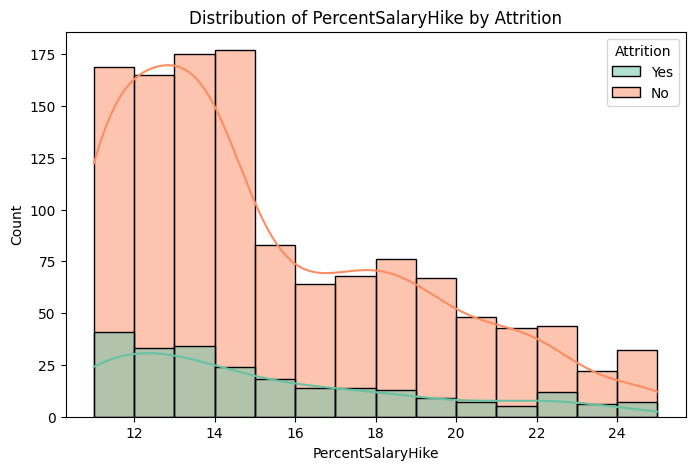

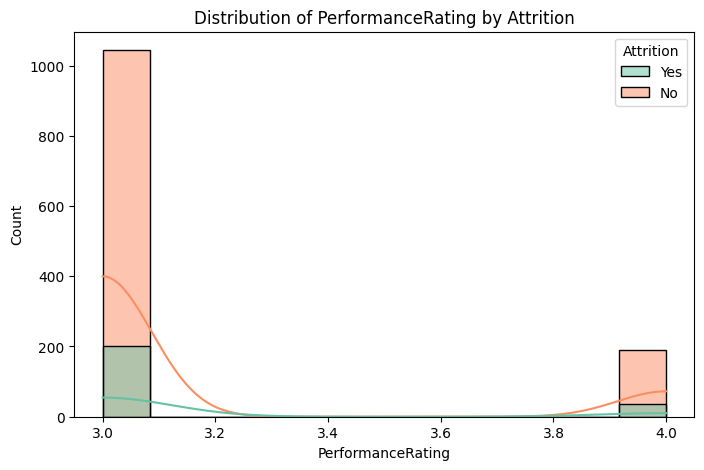

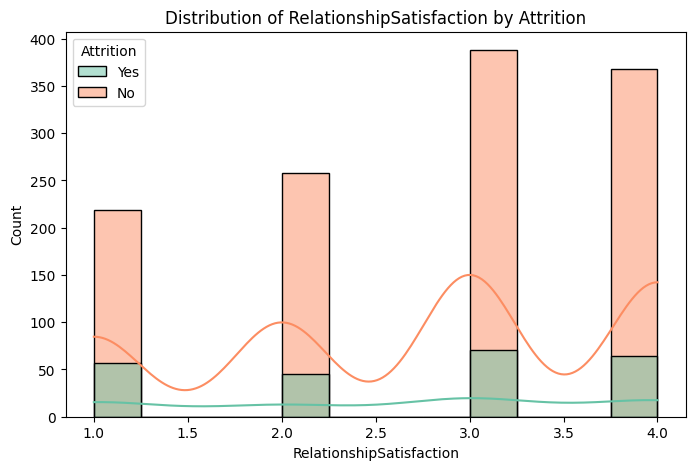

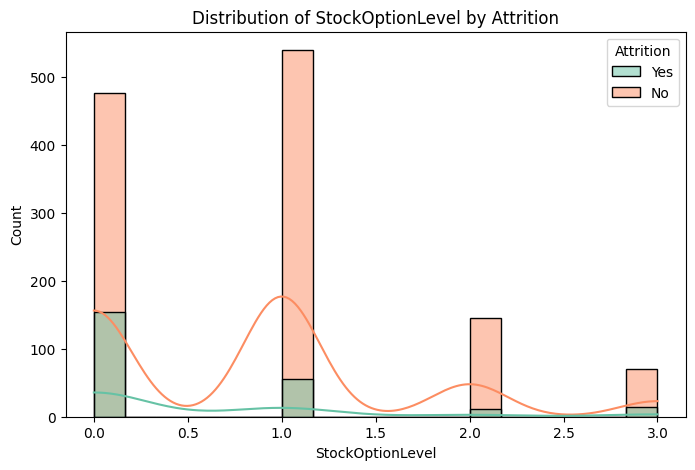

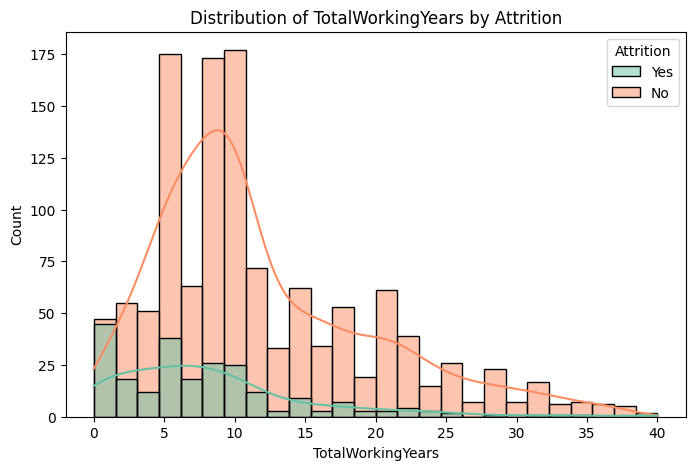

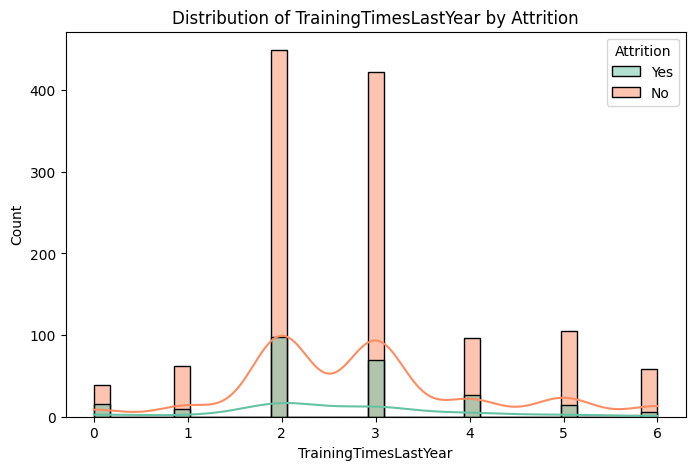

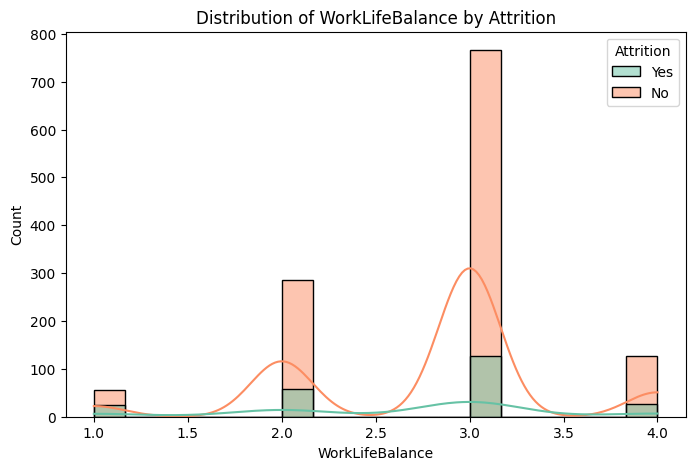

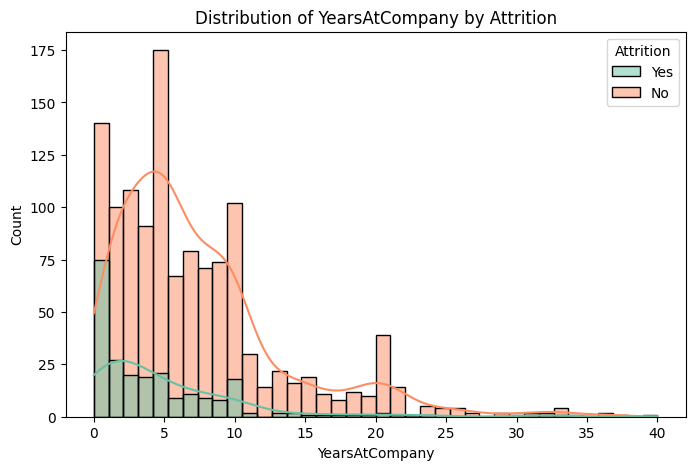

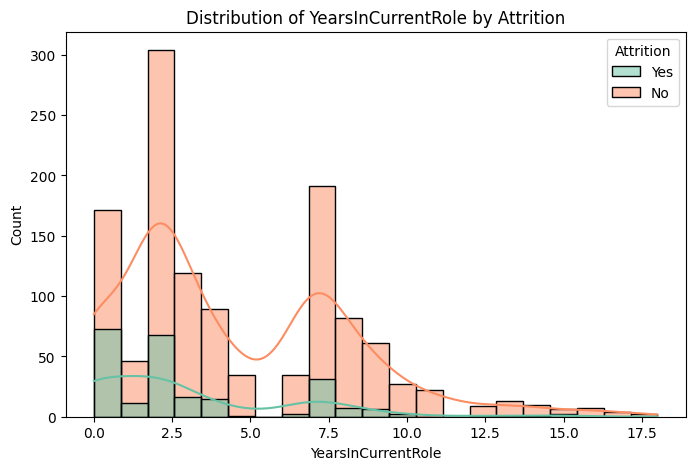

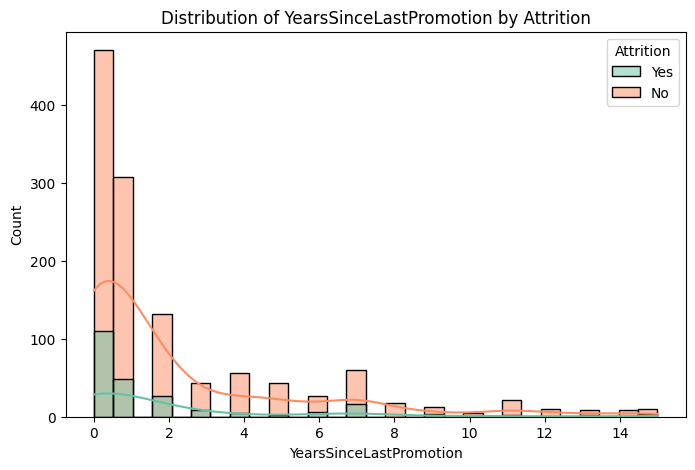

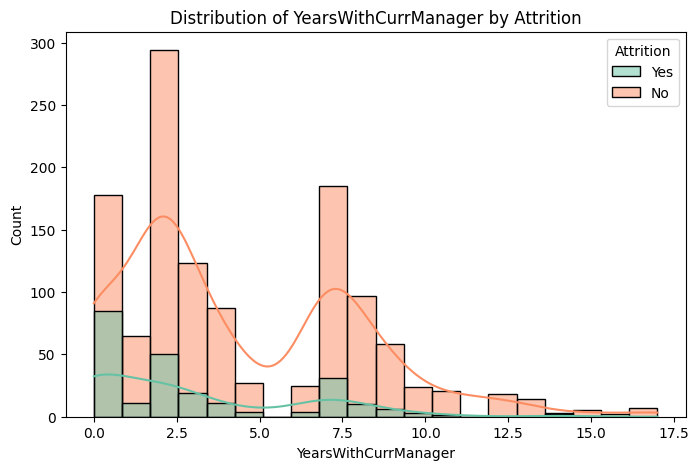

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 5))

    # Option 1: Histograms with KDE (Kernel Density Estimate)
    sns.histplot(x=col, hue='Attrition', data=df, kde=True, palette="Set2")
    plt.title(f'Distribution of {col} by Attrition')

    # Option 2: Box plots
    #sns.boxplot(x='Attrition', y=col, data=df)
    #plt.title(f'{col} vs. Attrition')

    plt.show()

    # Additional exploration: Correlation with Attrition (after one-hot encoding)

## 2.4 Correlation Analysis


Correlation with Attrition:
Attrition                            1.000000
OverTime_Yes                         0.246118
MaritalStatus_Single                 0.175419
JobRole_Sales Representative         0.157234
BusinessTravel_Travel_Frequently     0.115143
JobRole_Laboratory Technician        0.098290
Department_Sales                     0.080855
DistanceFromHome                     0.077924
EducationField_Technical Degree      0.069355
EducationField_Marketing             0.055781
NumCompaniesWorked                   0.043494
JobRole_Human Resources              0.036215
Gender_Male                          0.029453
JobRole_Sales Executive              0.019774
MonthlyRate                          0.015170
PerformanceRating                    0.002889
JobRole_Research Scientist          -0.000360
HourlyRate                          -0.006846
PercentSalaryHike                   -0.013478
EducationField_Other                -0.017898
Education                           -0.031373
Educa

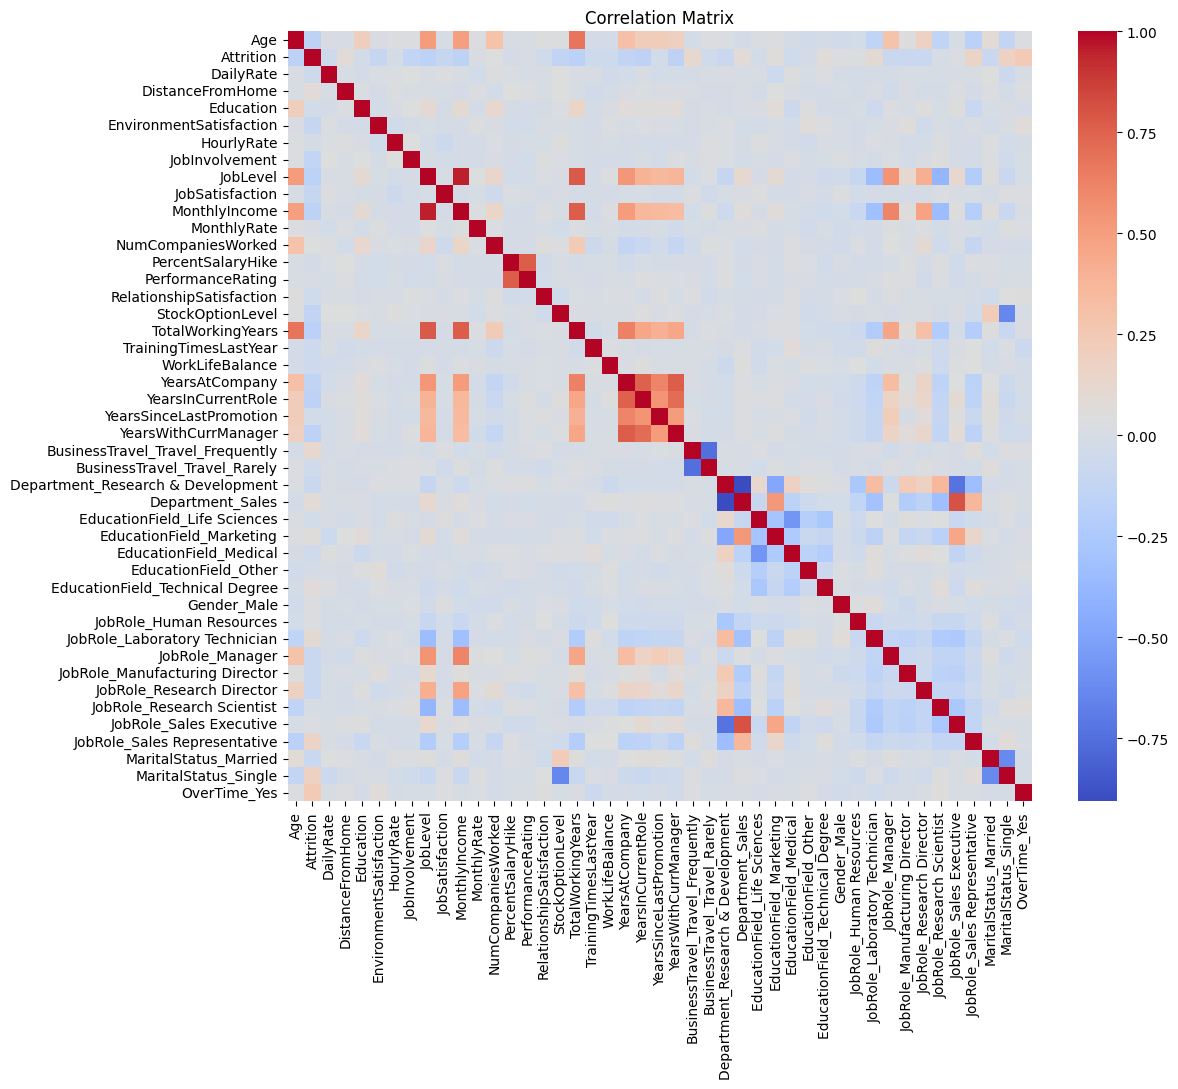

In [ ]:
# One-hot encode (like you did before, but only on the object columns)
df_encoded = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns.drop('Attrition'), drop_first=True)
df_encoded['Attrition'] = df_encoded['Attrition'].map({'Yes': 1, 'No': 0})

# Calculate the correlation matrix
corr_matrix = df_encoded.corr()

# Focus on correlation with 'Attrition'
attrition_correlation = corr_matrix['Attrition'].sort_values(ascending=False)
print("\nCorrelation with Attrition:")
print(attrition_correlation)

# Visualize with a heatmap
plt.figure(figsize=(12, 10))  # Make the heatmap larger
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")  # Show correlation values
plt.title('Correlation Matrix')
plt.show()

## Step 3: Feature Engineering

In [ ]:
# Age Groups
bins = [0, 25, 40, 60, 100]  # Define age bins
labels = ['Young', 'Early Career', 'Mid-Career', 'Late Career']
df_encoded['AgeGroup'] = pd.cut(df_encoded['Age'], bins=bins, labels=labels, right=False)
df_encoded = pd.get_dummies(df_encoded, columns=['AgeGroup'], prefix='AgeGroup',drop_first=True) #one-hot encode

# Total Satisfaction (example)
df_encoded['TotalSatisfaction'] = df_encoded['JobSatisfaction'] + df_encoded['EnvironmentSatisfaction'] + df_encoded['RelationshipSatisfaction']

## Step 4: Data Preprocessing for Machine Learning

In [ ]:
# Prepare data for modeling
x = df_encoded.drop('Attrition', axis=1)  # Features
y = df_encoded['Attrition']  # Target variable

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y) # stratify is important!

Accuracy: 0.8435

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294


Confusion Matrix:
 [[244   3]
 [ 43   4]]


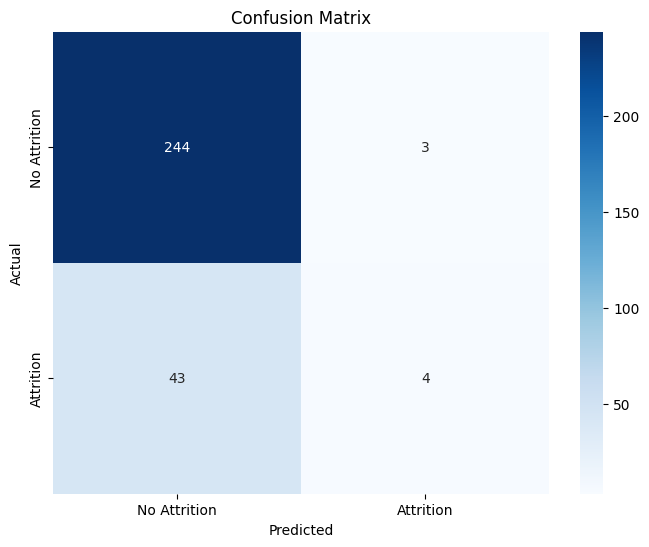

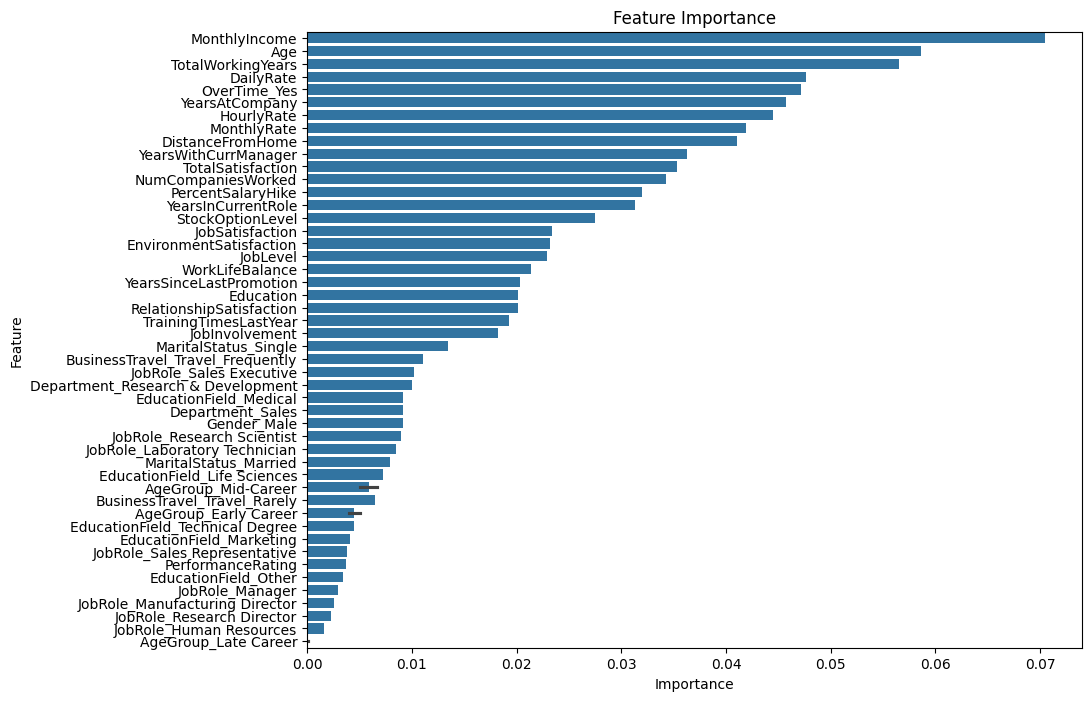

In [ ]:
# Initialize and train the Random Forest model
model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')  # Add class_weight
model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = model.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Attrition', 'Attrition'], yticklabels=['No Attrition', 'Attrition'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance
feature_importances = model.feature_importances_
features = x_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.show()